# The protect list, and a lookup that must fail out loud

**Week 2, Friday. Round 2 of 3.** By the end of this notebook you can build the top-fifty protect
list, find a member by id with an exact match, show why an approximate match hands back a neighbour
for a missing id, and total a filtered list so it adds only the rows a director can see.

> **The client asks.** "The top-fifty protect list, with a lookup so I can find any member by id."
>
> Meera's chief of staff, Kalpa Retail

> **Kavya's review.** "A lookup that cannot find an id says so. A lookup that answers with somebody
> else's row is worse than no lookup, because nobody in the room can tell."

Round 1 ended on a tree that reconciles and a clean table you reconciled yourself. The protect list is
Wednesday's list for the head of Retail-Plus, now read from the customer table across both quarters.

**Setup.** The same two exports and the same control totals as round 1.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

clean = pd.read_csv(kit.data_dir() / "C2_W02_D05_customer_table_STUDENT.csv")
raw = pd.read_csv(kit.data_dir() / "C2_W02_D05_raw_export_STUDENT.csv")
WAREHOUSE = {"Q1": 100_000_000, "Q2": 98_400_000}   # Monday's warehouse totals, from Week 2 Monday
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


print(len(clean), "customer rows and", len(raw), "export rows loaded")

300 customer rows and 1450 export rows loaded


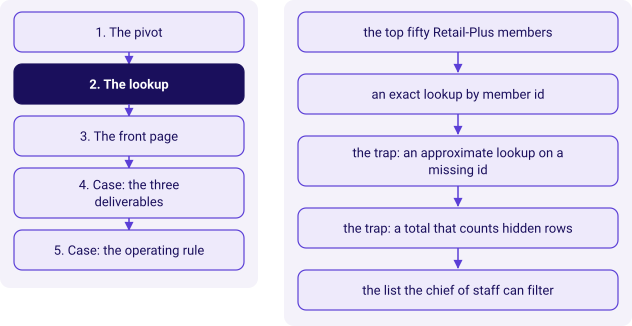

In [2]:
kit.side_by_side(
    kit.ladder(['The pivot', 'The lookup', 'The front page', 'Case: the three deliverables', 'Case: the operating rule'], lit=1, show=False),
    kit.vflow(['the top fifty Retail-Plus members', 'an exact lookup by member id', 'the trap: an approximate lookup on a missing id', 'the trap: a total that counts hidden rows', 'the list the chief of staff can filter'], show=False),
)

## 1. The top fifty

The head of Retail-Plus asked on Wednesday who to protect first. The list is the fifty Retail-Plus
members with the highest revenue across both quarters. In Excel: filter `segment` to Retail-Plus,
sort `revenue` largest to smallest, and keep the first fifty rows; in the deck pack a rank column
does it with `COUNTIFS`, so a director who changes the list size sees it recalculate.

**Predict before you run.** How many Retail-Plus members are in the customer table, and so how deep
does a top fifty reach? a) about half of them; b) all of them; c) the top tenth; d) fewer than fifty
exist.

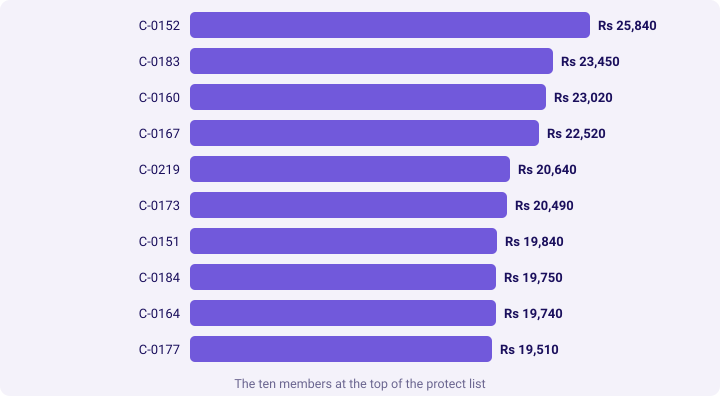

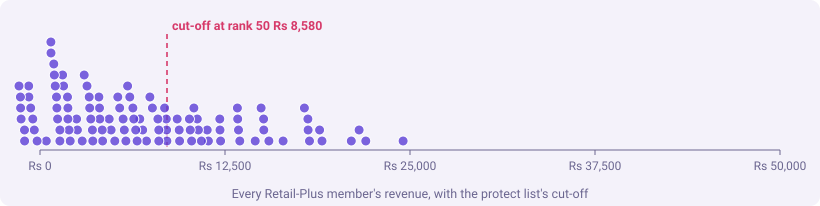

In [3]:
plus = clean[clean.segment == "Retail-Plus"].sort_values(["revenue", "customer_id"], ascending=[False, True])
plus = plus.reset_index(drop=True)
plus["rank"] = plus.index + 1
top = plus.head(50)
kit.stats([(f"{len(plus)}", "Retail-Plus members", "in the customer table"),
           (kit.rupees(top.revenue.sum()), "the top fifty's revenue", "both quarters"),
           (kit.rupees(top.revenue.iloc[-1]), "the fiftieth member", "the cut-off")])
kit.bars([(r.customer_id, int(r.revenue)) for r in top.head(10).itertuples()], fmt=kit.rupees,
         title="The ten members at the top of the protect list")
kit.strip(plus.revenue.tolist(), markers=[("cut-off at rank 50", int(top.revenue.iloc[-1]), "bad")],
          title="Every Retail-Plus member's revenue, with the protect list's cut-off")

**What happened.** The answer is a. There are 106 members, so the list keeps a little under half,
from Rs 25,840 at the top to Rs 8,580 at rank fifty. The next member spent Rs 8,520, so there is no
tie at the boundary this time, and the list ships exactly fifty rows.

In [4]:
kit.check("the list holds fifty members", len(top) == 50)
kit.check("every member on the list is Retail-Plus", set(top.segment) == {"Retail-Plus"})
kit.check("no tie sits across the fiftieth place", plus.revenue.iloc[49] != plus.revenue.iloc[50],
          f"{plus.revenue.iloc[49]} against {plus.revenue.iloc[50]}")

## 2. Find a member by id, exactly

The chief of staff types an id and wants the member's row. In Excel the lookup is
`=INDEX(revenue, MATCH(id, customer_id, 0))`, where the `0` asks for an exact match, or in the
room's Excel `=XLOOKUP(id, customer_id, revenue, "not in the table")`, whose match mode is exact by
default (Microsoft Support, XLOOKUP, verified 29 September 2026). In pandas, the id becomes the index.

**Predict before you run.** What should the lookup return for C-0152? a) the first row of the table;
b) C-0152's row; c) the nearest id below C-0152; d) an error, since ids are text.

C-0152: Retail-Plus, Pune, Rs 25,840, rank 1 of 50


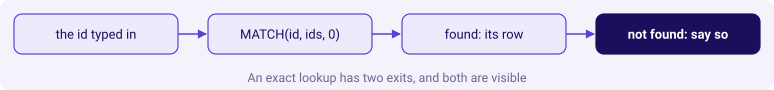

In [5]:
by_id = clean.set_index("customer_id")


def find(member):
    """An exact lookup that says so when the id is missing."""
    if member not in by_id.index:
        return "not in the table"
    row = by_id.loc[member]
    rank = plus.set_index("customer_id")["rank"].get(member)
    place = f"rank {rank} of 50" if rank is not None and rank <= 50 else "not on the list"
    return f"{member}: {row.segment}, {row.city}, {kit.rupees(row.revenue)}, {place}"


print(find("C-0152"))
kit.flow(["the id typed in", "MATCH(id, ids, 0)", "found: its row", "not found: say so"], lit=3,
         title="An exact lookup has two exits, and both are visible")

In [6]:
kit.check("the exact lookup returns the member asked for", find("C-0152").startswith("C-0152"))
kit.check("the exact lookup says so for an id that is not there", find("C-0195") == "not in the table")

**What happened.** The answer is b. C-0152 is the top of the list at Rs 25,840. The second check
tried C-0195, a Retail-Plus member with no orders in these two quarters, so the customer table has
no row for them, and the exact lookup says so.

## 3. The trap: an approximate lookup on a missing id

**The plausible wrong answer.** A hurried sheet uses `=VLOOKUP(id, table, 5)`. Its fourth argument
is left out, and Microsoft's page says the argument defaults to an approximate match (VLOOKUP,
verified 29 September 2026). On a table sorted by id, an approximate match returns the largest id not
above the one asked for.

In [7]:
ids = sorted(clean.customer_id)


def vlookup_approximate(member):
    """What VLOOKUP with its fourth argument left out returns on a table sorted by id."""
    below = [i for i in ids if i <= member]
    return below[-1] if below else "#N/A"


returned = vlookup_approximate("C-0195")
row = by_id.loc[returned]
rank = int(plus.set_index("customer_id").loc[returned, "rank"])
kit.table(["Asked for", "Row returned", "Revenue", "City", "What the sheet says"],
          [("C-0195", returned, kit.rupees(row.revenue), row.city, f"on the protect list at rank {rank}")],
          caption="The approximate lookup answers without a warning")

Asked for,Row returned,Revenue,City,What the sheet says
C-0195,C-0194,"Rs 16,740",Hyderabad,on the protect list at rank 15


**Why it is wrong.** The member asked for is not in the table, and the sheet answers with their
neighbour's row: Rs 16,740, Hyderabad, rank 15. In business terms, the chief of staff tells a director
that C-0195 is one of Kalpa's best members and on the list, and a retention offer goes to someone who
has not bought in six months, while nobody asks why the id was missing. Nothing on the screen looks
wrong. The check is to compare the id returned with the id asked for.

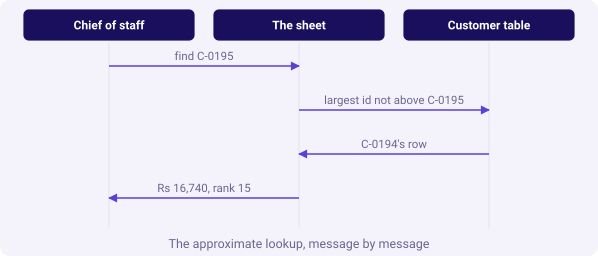

In [8]:
kit.sequence(["Chief of staff", "The sheet", "Customer table"],
             [("Chief of staff", "The sheet", "find C-0195"),
              ("The sheet", "Customer table", "largest id not above C-0195"),
              ("Customer table", "The sheet", "C-0194's row"),
              ("The sheet", "Chief of staff", "Rs 16,740, rank 15")],
             title="The approximate lookup, message by message")
kit.check("the approximate lookup returns a different member", returned != "C-0195", returned)
kit.check("the neighbour it returns sits on the protect list", rank <= 50, f"rank {rank}")

**The fix.** An exact match with a visible not-found path: `=IFERROR(INDEX(revenue, MATCH(id, ids,
0)), "not in the table")`, or `XLOOKUP` with its fourth argument filled in. The fix changes one answer
from "rank 15, Rs 16,740" to "not in the table", which is the answer that makes somebody check the
export.

In [9]:
answers = [("C-0152", find("C-0152"), vlookup_approximate("C-0152")),
           ("C-0195", find("C-0195"), vlookup_approximate("C-0195")),
           ("C-0999", find("C-0999"), vlookup_approximate("C-0999"))]
kit.table(["Id asked for", "Exact lookup", "Approximate lookup returns"], answers,
          caption="Three ids, both lookups: only the exact one says when an id is missing")
kit.check("both lookups agree on an id that is there", answers[0][2] == "C-0152")
kit.check("an id past the end also gets a neighbour from the approximate lookup", answers[2][2] == ids[-1],
          answers[2][2])

Id asked for,Exact lookup,Approximate lookup returns
C-0152,"C-0152: Retail-Plus, Pune, Rs 25,840, rank 1 of 50",C-0152
C-0195,not in the table,C-0194
C-0999,not in the table,C-0340


**Your turn.** The head of Retail-Plus will read out one member id in the room, a member she knows
well. Type the id into the empty cell below with both lookups, run it, and say what each one tells you
and which one you would let the chief of staff read aloud:

```python
member = "..."          # the id read out in the room
print(find(member))
print(vlookup_approximate(member))
```

## 4. The trap: a total that counts rows a filter hid

The chief of staff filters the protect list to Mumbai before a call with the Mumbai store head and
reads the total at the foot of the list.

**The plausible wrong answer.** The foot is `=SUM(E12:E61)`. In Excel, rows hidden by a filter drop
out of `SUBTOTAL`, and `SUM` still adds them; with rows hidden by hand, `SUBTOTAL(109)` ignores them
and `SUBTOTAL(9)` does not (SUBTOTAL, verified 29 September 2026). On LibreOffice 24.2.7.2, `SUM`
over three rows with one hidden returned 60 where `SUBTOTAL(109)` returned 40.

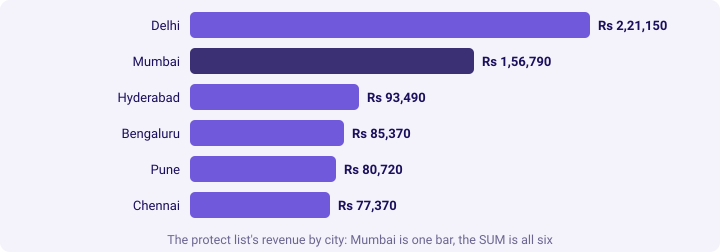

In [10]:
top = top.assign(visible=top.city == "Mumbai")
foot_sum = int(top.revenue.sum())
foot_visible = int(top.loc[top.visible, "revenue"].sum())
kit.stats([(kit.rupees(foot_sum), "SUM at the foot", "all fifty rows"),
           (kit.rupees(foot_visible), "SUBTOTAL(109)", f"the {int(top.visible.sum())} Mumbai rows you can see"),
           (f"{foot_sum / foot_visible:.1f} times", "the overstatement", "read as Mumbai's list")])
by_city = top.groupby("city").revenue.sum().sort_values(ascending=False)
kit.bars([(c, int(v)) for c, v in by_city.items()], fmt=kit.rupees, lit=[list(by_city.index).index("Mumbai")],
         title="The protect list's revenue by city: Mumbai is one bar, the SUM is all six")

**Why it is wrong.** The Mumbai store head is told the members on their list spent Rs 7.15 lakh, when
the eleven on screen spent Rs 1.57 lakh, and a retention budget sized on the first number is four and
a half times too big. The check is to count what the foot counts: `=SUBTOTAL(102, E12:E61)` counts
only visible numbers, and if that count is smaller than the rows the total adds, the total is adding
hidden rows. The fix is `=SUBTOTAL(109, E12:E61)`, which the deck pack uses.

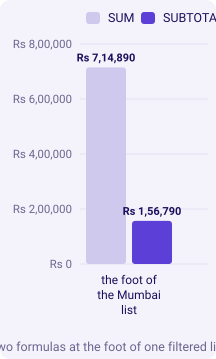

In [11]:
kit.columns(["the foot of the Mumbai list"], [("SUM", [foot_sum]), ("SUBTOTAL(109)", [foot_visible])],
            fmt=kit.rupees, title="Two formulas at the foot of one filtered list")
kit.check("the foot SUM counts rows the filter hid", foot_sum > foot_visible)
kit.check("the visible total is Mumbai's eleven members", int(top.visible.sum()) == 11, f"{int(top.visible.sum())} rows")
kit.check("the visible total is less than a quarter of the SUM", foot_visible / foot_sum < 0.25,
          f"{foot_visible / foot_sum:.1%}")

> **Kavya's review.** "Two checks before a list leaves the team. Ask the lookup for an id you know is
> missing and watch it say so. Filter the list and count what the foot adds. Neither takes a minute,
> and both failures are silent."

### In the interview

**[S] A stakeholder wants to poke the numbers themselves. What do you give them, and what do you never
give them?** I give them a finished table that reconciles to the source of truth, with the inputs
they may change marked and everything else computed: a list they can filter, a lookup that says
"not in the table", a total that follows their filter. I never give them the source itself to edit,
a lookup that can answer with the wrong row, or a number whose definition is not on the sheet,
because each of those lets the room change the answer without anybody seeing it change.

**[F] Your lookup returned a member for an id that does not exist. What went wrong?** The match type.
`VLOOKUP` with its fourth argument left out, or `MATCH` with 1, returns the nearest id below on a
sorted table. The fix is an exact match with a not-found path, and the habit is to test every lookup
with an id you know is missing before anyone else uses it.

### Depth: why XLOOKUP is taught and INDEX and MATCH ship

`XLOOKUP` defaults to an exact match and takes an `if_not_found` argument, which makes the safe
lookup the short one. It arrived after the LibreOffice this programme proves workbooks on: LibreOffice
24.2.7.2 returns `#NAME?` for it, checked on 29 September 2026. So the workbooks compute with `INDEX`
and `MATCH`, and the one `XLOOKUP` cell in the deck pack is labelled as computed in Excel and not
proved here.

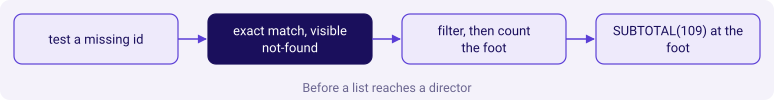

What this round established,The number
the protect list,"50 Retail-Plus members, Rs 7,14,890, cut-off Rs 8,580"
an approximate lookup on C-0195,"C-0194's row, rank 15, Rs 16,740"
the exact lookup on C-0195,not in the table
"the list filtered to Mumbai, SUM","Rs 7,14,890"
"the list filtered to Mumbai, SUBTOTAL(109)","Rs 1,56,790 for 11 members"


In [12]:
kit.flow(["test a missing id", "exact match, visible not-found", "filter, then count the foot",
          "SUBTOTAL(109) at the foot"], lit=1, title="Before a list reaches a director")
kit.table(["What this round established", "The number"],
          [("the protect list", "50 Retail-Plus members, Rs 7,14,890, cut-off Rs 8,580"),
           ("an approximate lookup on C-0195", "C-0194's row, rank 15, Rs 16,740"),
           ("the exact lookup on C-0195", "not in the table"),
           ("the list filtered to Mumbai, SUM", "Rs 7,14,890"),
           ("the list filtered to Mumbai, SUBTOTAL(109)", "Rs 1,56,790 for 11 members")])
kit.check_summary()

Round 3 puts one number on the front page and asks what it needs beside it to be read correctly.